In [1]:
import os
import pandas as pd

url = "https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv"

os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

total_data = pd.read_csv(url)
total_data.to_csv("../data/raw/total_data.csv", index=False)

total_data.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
#explore datat
total_data.shape
total_data.info()
total_data.isnull().sum()
total_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [3]:
#data cleaning
print("Duplicated full rows:", total_data.duplicated().sum())
print("Duplicated id:", total_data["id"].duplicated().sum())
print("Duplicated host_id:", total_data["host_id"].duplicated().sum())
print("Duplicated name:", total_data["name"].duplicated().sum())

data = total_data.copy()

data["last_review"] = pd.to_datetime(data["last_review"], errors="coerce")
data["reviews_per_month"] = data["reviews_per_month"].fillna(0)
data["has_review"] = data["last_review"].notnull().astype(int)

data.drop(["id", "name", "host_name", "last_review"], axis=1, inplace=True)

data.head()


Duplicated full rows: 0
Duplicated id: 0
Duplicated host_id: 11438
Duplicated name: 989


,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_review
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,1
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,1
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,0
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,1
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,1


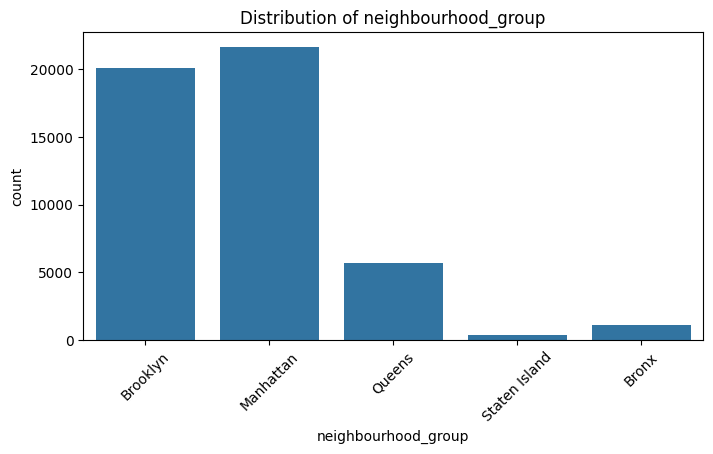

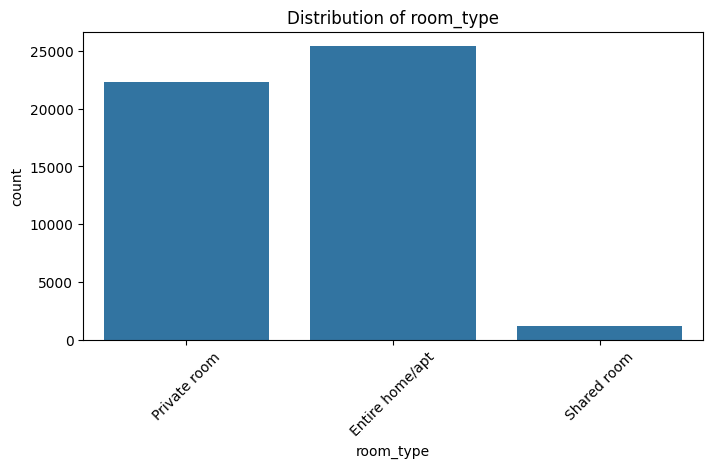

In [4]:
#analysis categorical variables
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = ["neighbourhood_group", "room_type"]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

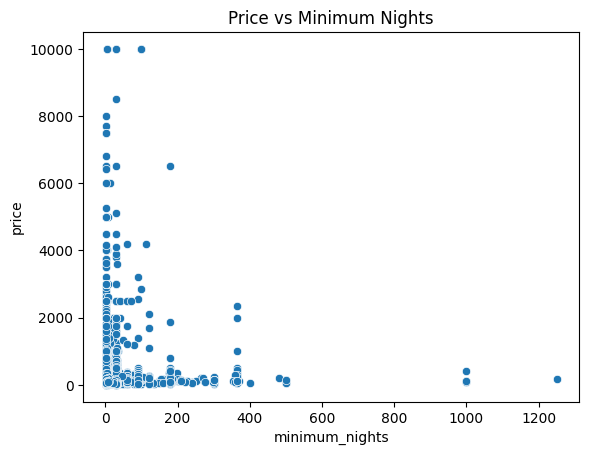

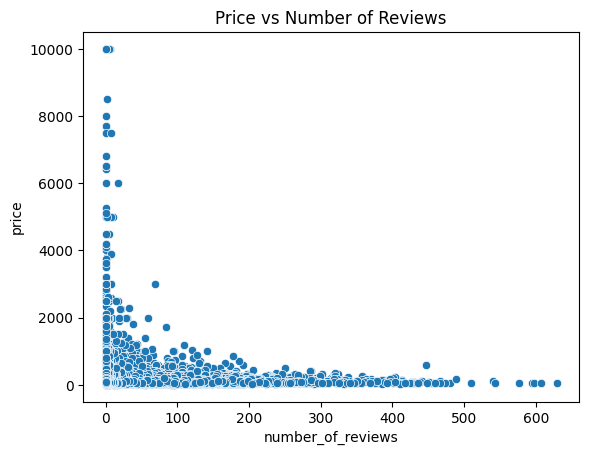

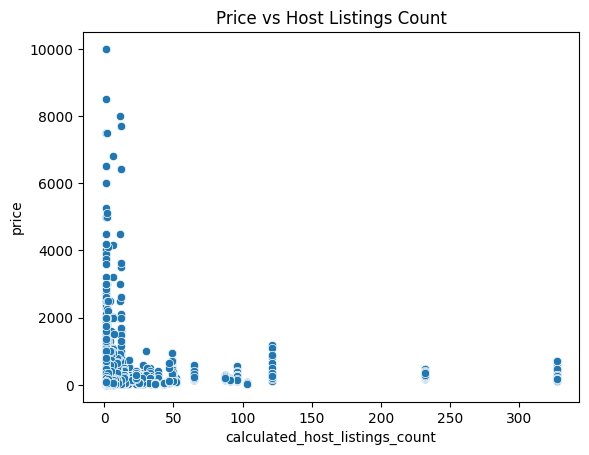

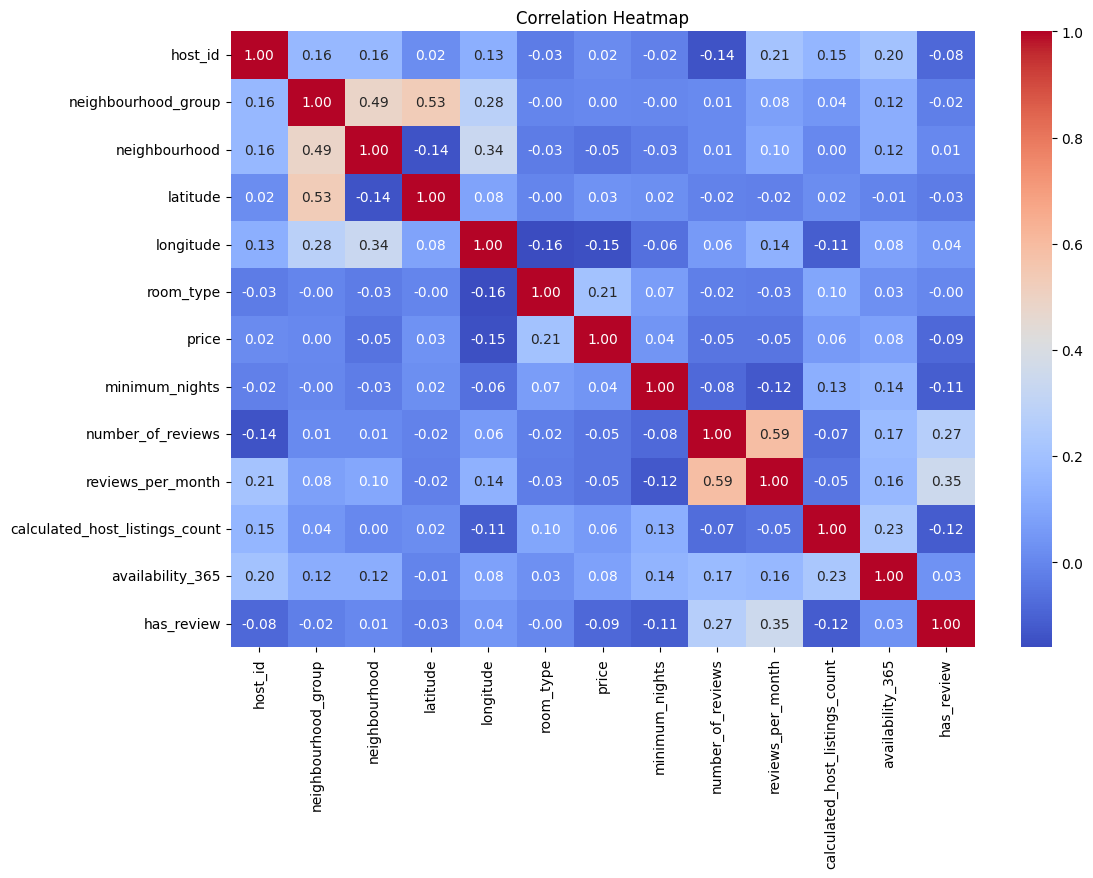

In [5]:
#analysis on numerical variables
#numerical vs. numerical 
sns.scatterplot(data=data, x="minimum_nights", y="price")
plt.title("Price vs Minimum Nights")
plt.show()

sns.scatterplot(data=data, x="number_of_reviews", y="price")
plt.title("Price vs Number of Reviews")
plt.show()

sns.scatterplot(data=data, x="calculated_host_listings_count", y="price")
plt.title("Price vs Host Listings Count")
plt.show()

#correlation heat map
corr_data = data.copy()

corr_data["room_type"] = pd.factorize(corr_data["room_type"])[0]
corr_data["neighbourhood_group"] = pd.factorize(corr_data["neighbourhood_group"])[0]
corr_data["neighbourhood"] = pd.factorize(corr_data["neighbourhood"])[0]

plt.figure(figsize=(12, 8))
sns.heatmap(corr_data.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

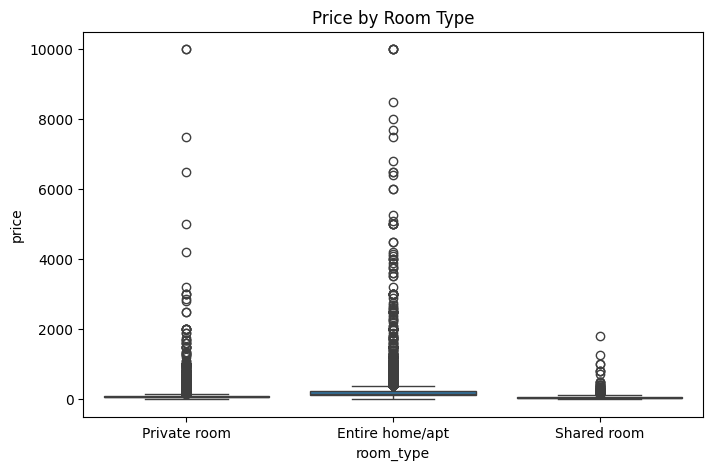

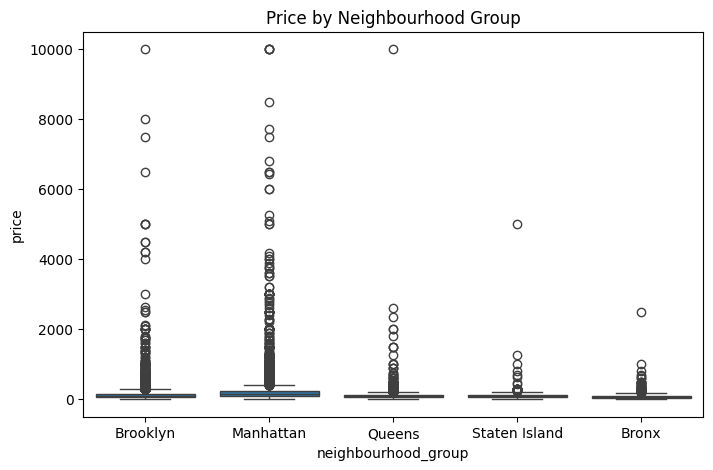

In [6]:
 #categorical vs. numerical
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="room_type", y="price")
plt.title("Price by Room Type")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="neighbourhood_group", y="price")
plt.title("Price by Neighbourhood Group")
plt.show()

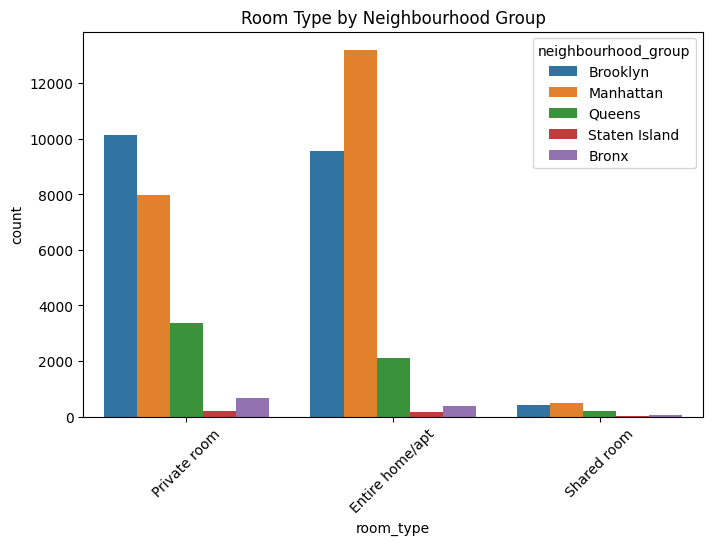

In [7]:
#categorical vs. categorical 
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="room_type", hue="neighbourhood_group")
plt.title("Room Type by Neighbourhood Group")
plt.xticks(rotation=45)
plt.show()

In [8]:
# 8. OUTLIER TREATMENT
# ============================================
# Keep only realistic values for price and minimum_nights

# Remove price <= 0
data = data[data["price"] > 0]

# Cap extreme values using IQR
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

# For price
price_lower, price_upper = iqr_bounds(data["price"])
print("Price upper bound:", price_upper)

# For minimum_nights
nights_lower, nights_upper = iqr_bounds(data["minimum_nights"])
print("Minimum nights upper bound:", nights_upper)

# Apply clipping instead of deleting too much data
data["price"] = data["price"].clip(lower=1, upper=price_upper)
data["minimum_nights"] = data["minimum_nights"].clip(lower=1, upper=nights_upper)

# Optional clipping for host listing count
host_lower, host_upper = iqr_bounds(data["calculated_host_listings_count"])
data["calculated_host_listings_count"] = data["calculated_host_listings_count"].clip(
    lower=1, upper=host_upper
)

print(data.shape)

Price upper bound: 334.0
Minimum nights upper bound: 11.0
(48884, 13)


In [9]:
# 8. OUTLIER TREATMENT
# ============================================
# Keep only realistic values for price and minimum_nights

# Remove price <= 0
data = data[data["price"] > 0]

# Cap extreme values using IQR
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

# For price
price_lower, price_upper = iqr_bounds(data["price"])
print("Price upper bound:", price_upper)

# For minimum_nights
nights_lower, nights_upper = iqr_bounds(data["minimum_nights"])
print("Minimum nights upper bound:", nights_upper)

# Apply clipping instead of deleting too much data
data["price"] = data["price"].clip(lower=1, upper=price_upper)
data["minimum_nights"] = data["minimum_nights"].clip(lower=1, upper=nights_upper)

# Optional clipping for host listing count
host_lower, host_upper = iqr_bounds(data["calculated_host_listings_count"])
data["calculated_host_listings_count"] = data["calculated_host_listings_count"].clip(
    lower=1, upper=host_upper
)

print(data.shape)

Price upper bound: 334.0
Minimum nights upper bound: 11.0
(48884, 13)


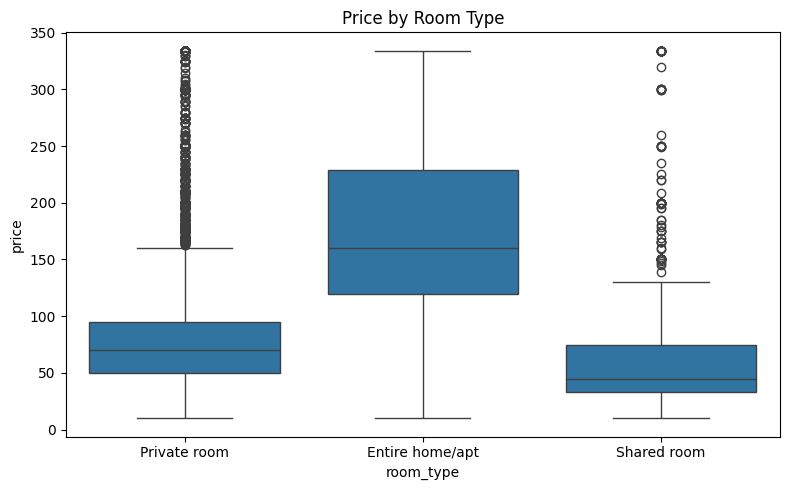

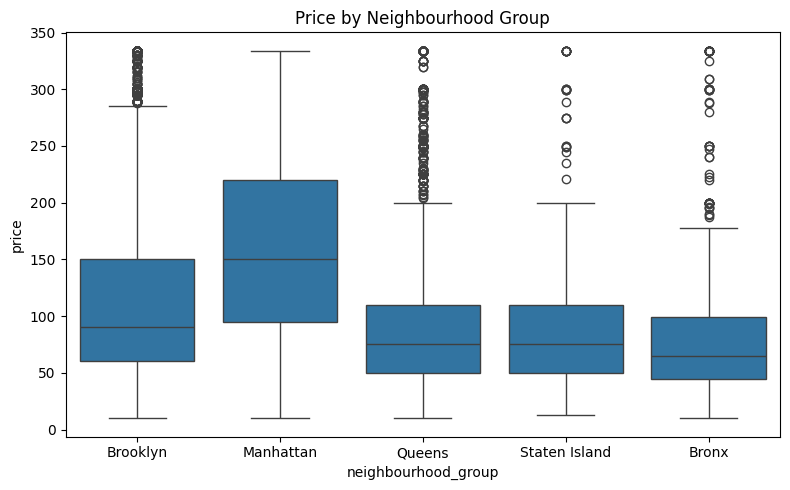

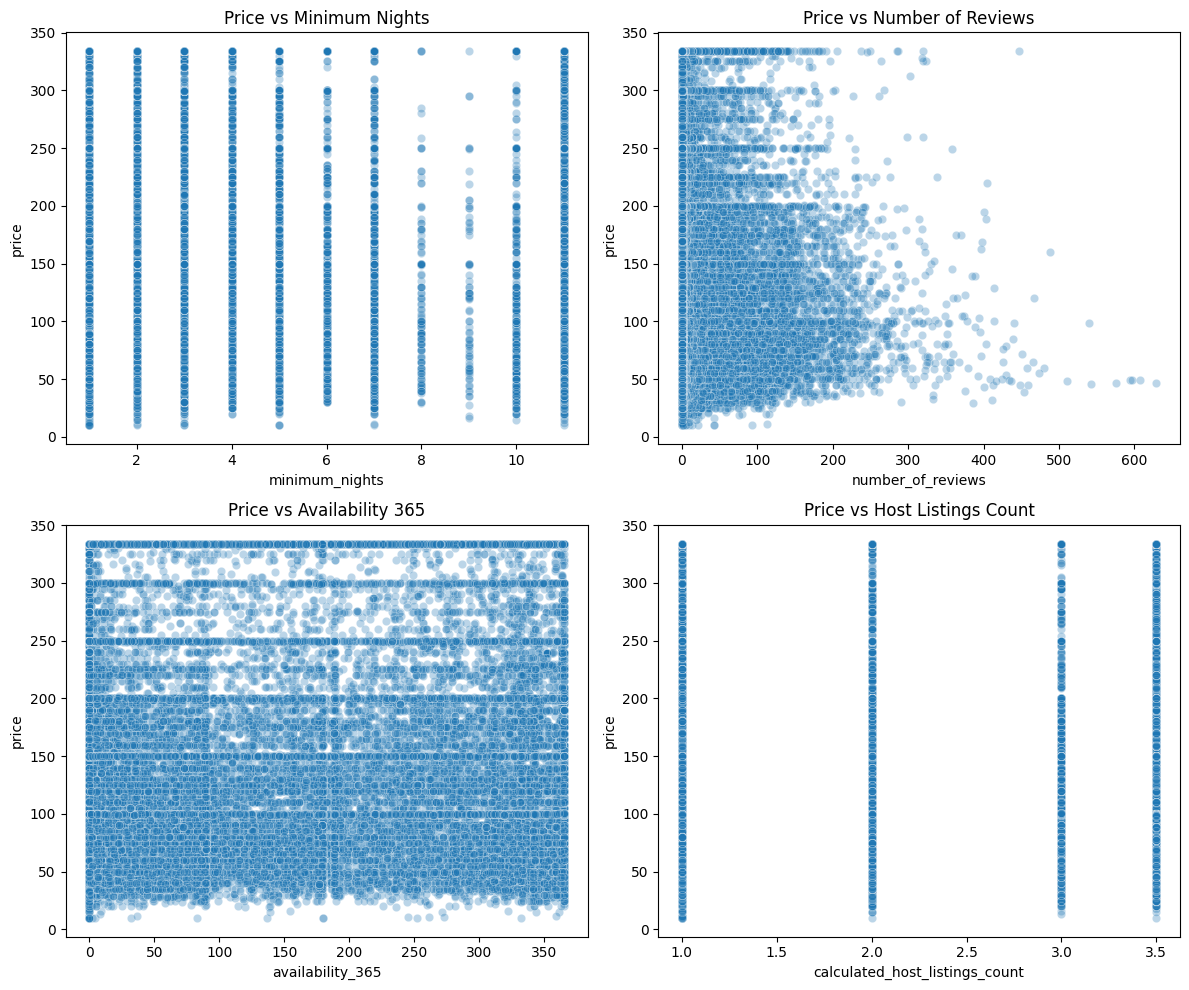

In [10]:
# 10. BIVARIATE ANALYSIS
# ============================================

# Price by room type
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="room_type", y="price")
plt.title("Price by Room Type")
plt.tight_layout()
plt.show()

# Price by neighbourhood group
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="neighbourhood_group", y="price")
plt.title("Price by Neighbourhood Group")
plt.tight_layout()
plt.show()

# Scatterplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(data=data, x="minimum_nights", y="price", alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_title("Price vs Minimum Nights")

sns.scatterplot(data=data, x="number_of_reviews", y="price", alpha=0.3, ax=axes[0, 1])
axes[0, 1].set_title("Price vs Number of Reviews")

sns.scatterplot(data=data, x="availability_365", y="price", alpha=0.3, ax=axes[1, 0])
axes[1, 0].set_title("Price vs Availability 365")

sns.scatterplot(data=data, x="calculated_host_listings_count", y="price", alpha=0.3, ax=axes[1, 1])
axes[1, 1].set_title("Price vs Host Listings Count")

plt.tight_layout()
plt.show()

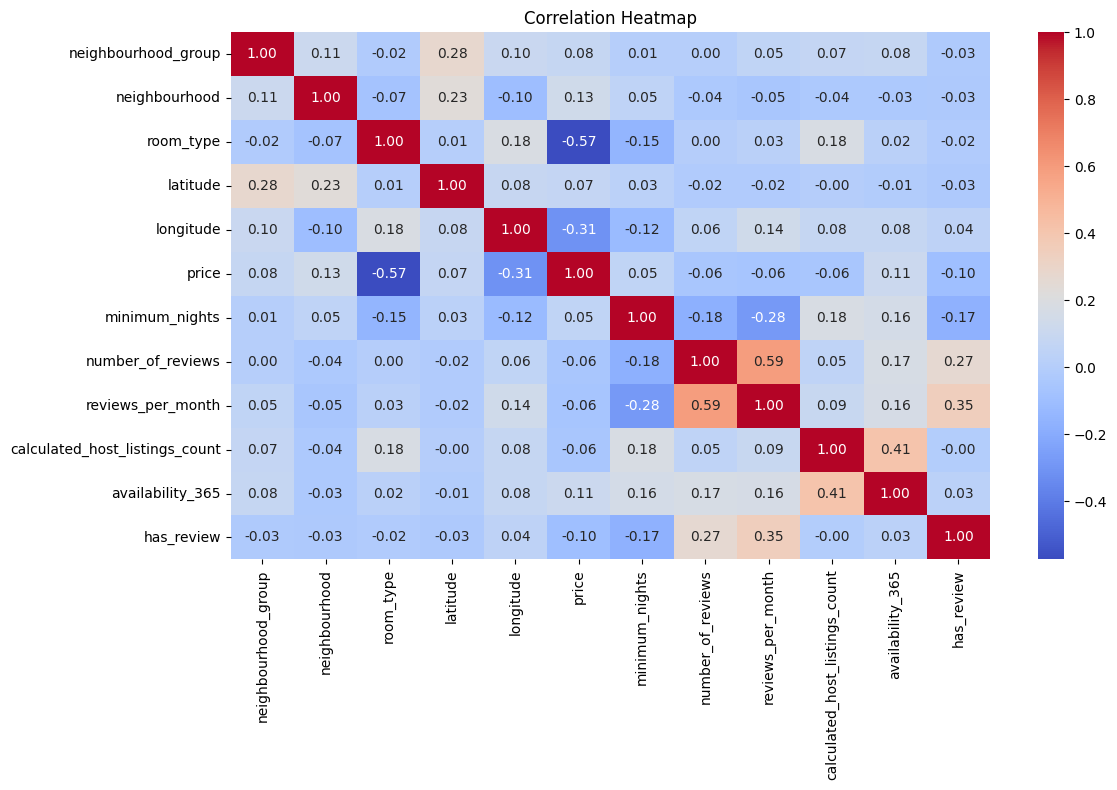

In [12]:
# 11. CORRELATION ANALYSIS
# ============================================
# Encode categorical features for heatmap only
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

corr_data = data.copy()

encoder = OrdinalEncoder()
corr_data[["neighbourhood_group", "neighbourhood", "room_type"]] = encoder.fit_transform(
    corr_data[["neighbourhood_group", "neighbourhood", "room_type"]]
)

corr_cols = [
    "neighbourhood_group", "neighbourhood", "room_type",
    "latitude", "longitude", "price", "minimum_nights",
    "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365", "has_review"
]

plt.figure(figsize=(12, 8))
sns.heatmap(corr_data[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [14]:
# 12. INSIGHTS
# ============================================
print("Top neighbourhood groups by average price:")
print(data.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False))
print()

print("Top room types by average price:")
print(data.groupby("room_type")["price"].mean().sort_values(ascending=False))
print()

print("Correlation with price:")
print(corr_data[corr_cols].corr()["price"].sort_values(ascending=False))

Top neighbourhood groups by average price:
neighbourhood_group
Manhattan        164.668790
Brooklyn         113.574720
Staten Island     94.485255
Queens            93.186904
Bronx             82.380734
Name: price, dtype: float64

Top room types by average price:
room_type
Entire home/apt    180.222380
Private room        82.813343
Shared room         64.614853
Name: price, dtype: float64

Correlation with price:
price                             1.000000
neighbourhood                     0.133776
availability_365                  0.112792
neighbourhood_group               0.082073
latitude                          0.073768
minimum_nights                    0.053397
calculated_host_listings_count   -0.056449
number_of_reviews                -0.057611
reviews_per_month                -0.061938
has_review                       -0.096267
longitude                        -0.311697
room_type                        -0.574388
Name: price, dtype: float64


In [15]:
# 13. PREPARE DATA FOR TRAIN / TEST
# ============================================
model_data = data.copy()

# Encode categorical columns
categorical_features = ["neighbourhood_group", "neighbourhood", "room_type"]
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
model_data[categorical_features] = encoder.fit_transform(model_data[categorical_features])

# Select final features
final_features = [
    "host_id",
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "has_review"
]

X = model_data[final_features]
y = model_data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_data = X_train.copy()
train_data["price"] = y_train

test_data = X_test.copy()
test_data["price"] = y_test

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)


# 14. SAVE PROCESSED DATA
# ============================================
train_data.to_csv("../data/processed/clean_train.csv", index=False)
test_data.to_csv("../data/processed/clean_test.csv", index=False)

print("Files saved successfully:")
print("../data/raw/total_data.csv")
print("../data/processed/clean_train.csv")
print("../data/processed/clean_test.csv")

Train shape: (39107, 13)
Test shape: (9777, 13)
Files saved successfully:
../data/raw/total_data.csv
../data/processed/clean_train.csv
../data/processed/clean_test.csv
